# Lab Assignment — Pre-trained Model Implementation


**Lab Title**

Pneumonia Detection from Chest X-Rays using SqueezeNet

Name: Samriddhi Das

Student PRN: 202301040276

Group Members: Swayam Pagare, Jayesh Jadhav, Manish Korde

**Selected Research Paper**

Title: SqueezeNet: AlexNet-level accuracy with 50x fewer parameters

Authors: Forrest N. Iandola, Song Han, et al.

Publised by arXiv

**Paper Summary**

SqueezeNet is a lightweight CNN architecture that achieves **AlexNet-level accuracy on ImageNet** with:
- **50× fewer parameters** than AlexNet
- A model size of **< 0.5 MB** (vs. AlexNet's 240 MB)
- A novel **Fire Module** design (squeeze + expand layers)

##### **Why we have chosen SqueezeNet for Pneumonia Detection?**
Medical imaging applications often require lightweight models deployable on edge devices (tablets, portable scanners). SqueezeNet's small footprint makes it ideal for resource-constrained clinical environments while maintaining strong accuracy.

###  TASK 1 — Imports, Environment & GPU Check

In [ ]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score
import pandas as pd

print("TensorFlow version :", tf.__version__)
print("GPU available      :", tf.config.list_physical_devices('GPU'))

2026-04-05 19:54:43.918793: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775418884.082953      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775418884.132347      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775418884.510741      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775418884.510786      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775418884.510788      55 computation_placer.cc:177] computation placer alr

TensorFlow version : 2.19.0
GPU available      : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


**Dataset Name**

Chest X-Ray Pneumonia Dataset

**Dataset Link**

https://www.kaggle.com/datasets/iamtanmayshukla/pneumonia-radiography-dataset?utm_source=chatgpt.com

**Published in:** Cell Journal — *Identifying Medical Diagnoses and Treatable Diseases by Image-Based Deep Learning* (Kermany et al., 2018)


**Dataset Description**

This dataset contains chest X-ray images used to detect pneumonia (lung infection). It is widely used for deep learning and medical image classification tasks.

Total Images: ~5,800+

Image Type: Grayscale X-ray images which is in JPEG format

**Classes:** 2 — `NORMAL` and `PNEUMONIA`

**Pre-split:** Train / Validation / Test folders provided

**Image source:** Pediatric patients aged 1–5 years from Guangzhou

**Labelling:** Graded by expert physicians, verified by a third expert

###  TASK 1 — Dataset Loading & Directory Setup

In [ ]:
import os

base = '/kaggle/input/chest-xray-pneumonia/chest_xray'

# Verify path
if not os.path.exists(base):
    for root, dirs, files in os.walk('/kaggle/input'):
        if 'chest_xray' in dirs:
            base = os.path.join(root, 'chest_xray')
            break
        if any(d in ['NORMAL', 'PNEUMONIA'] for d in dirs):
            base = root
            break

print("Base directory :", base)
print("Contents       :", os.listdir(base))

Base directory : /kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray
Contents       : ['chest_xray', '__MACOSX', 'val', 'test', 'train']


In [ ]:
train_dir = os.path.join(base, 'train')
val_dir   = os.path.join(base, 'val')
test_dir  = os.path.join(base, 'test')

print("Train exists :", os.path.exists(train_dir))
print("Val exists   :", os.path.exists(val_dir))
print("Test exists  :", os.path.exists(test_dir))

classes = sorted([
    d for d in os.listdir(train_dir)
    if os.path.isdir(os.path.join(train_dir, d))
])

print(f"\nClasses : {classes}")

Train exists : True
Val exists   : True
Test exists  : True

Classes : ['NORMAL', 'PNEUMONIA']


In [ ]:
print("Sample counts per split:\n")
for split_name, split_path in [('Train', train_dir),
                                ('Val',   val_dir),
                                ('Test',  test_dir)]:
    print(f"  {split_name}:")
    total = 0
    for cls in classes:
        cls_path = os.path.join(split_path, cls)
        if os.path.exists(cls_path):
            count  = len(os.listdir(cls_path))
            total += count
            print(f"    {cls:15s}: {count} images")
    print(f"    {'Total':15s}: {total} images\n")

Sample counts per split:

  Train:
    NORMAL         : 1341 images
    PNEUMONIA      : 3875 images
    Total          : 5216 images

  Val:
    NORMAL         : 8 images
    PNEUMONIA      : 8 images
    Total          : 16 images

  Test:
    NORMAL         : 234 images
    PNEUMONIA      : 390 images
    Total          : 624 images



###  TASK 1 — Sample Image Visualization

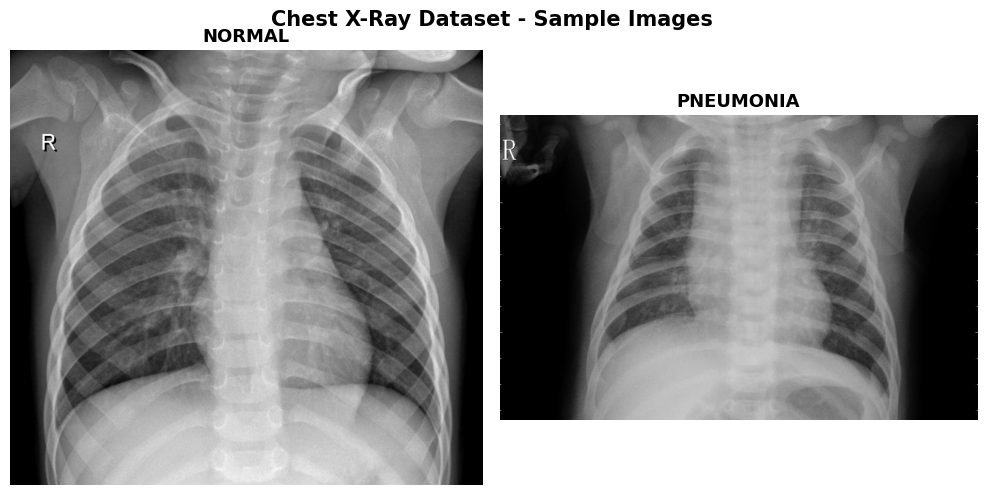

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle("Chest X-Ray Dataset - Sample Images",
             fontsize=15, fontweight='bold')

for ax, cls in zip(axes.flatten(), classes):
    cls_path = os.path.join(train_dir, cls)
    img_file = random.choice(os.listdir(cls_path))
    img      = mpimg.imread(os.path.join(cls_path, img_file))
    ax.imshow(img, cmap='gray')
    ax.set_title(cls.upper(), fontsize=13, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.show()

###  TASK 1 — Data Preprocessing & Augmentation

In [ ]:
IMG_SIZE   = (224, 224)
BATCH_SIZE = 32
SEED       = 42

# Count classes for class weights
normal_count    = len(os.listdir(os.path.join(train_dir, 'NORMAL')))
pneumonia_count = len(os.listdir(os.path.join(train_dir, 'PNEUMONIA')))
total_count     = normal_count + pneumonia_count

class_weight = {
    0: total_count / (2 * normal_count),
    1: total_count / (2 * pneumonia_count)
}

print(f"NORMAL count    : {normal_count}")
print(f"PNEUMONIA count : {pneumonia_count}")
print(f"Class weights   : {class_weight}")

# Augmentation for training
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.15,
    horizontal_flip=True,
    brightness_range=[0.9, 1.1],
    fill_mode='nearest'
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    seed=SEED,
    shuffle=True
)

val_gen = test_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

test_gen = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

print(f"\nTrain batches      : {len(train_gen)}")
print(f"Validation batches : {len(val_gen)}")
print(f"Test batches       : {len(test_gen)}")
print(f"Class indices      : {train_gen.class_indices}")

NORMAL count    : 1341
PNEUMONIA count : 3875
Class weights   : {0: 1.9448173005219984, 1: 0.6730322580645162}
Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.

Train batches      : 163
Validation batches : 1
Test batches       : 20
Class indices      : {'NORMAL': 0, 'PNEUMONIA': 1}


### TASK 1 — Data Augmentation Visualization

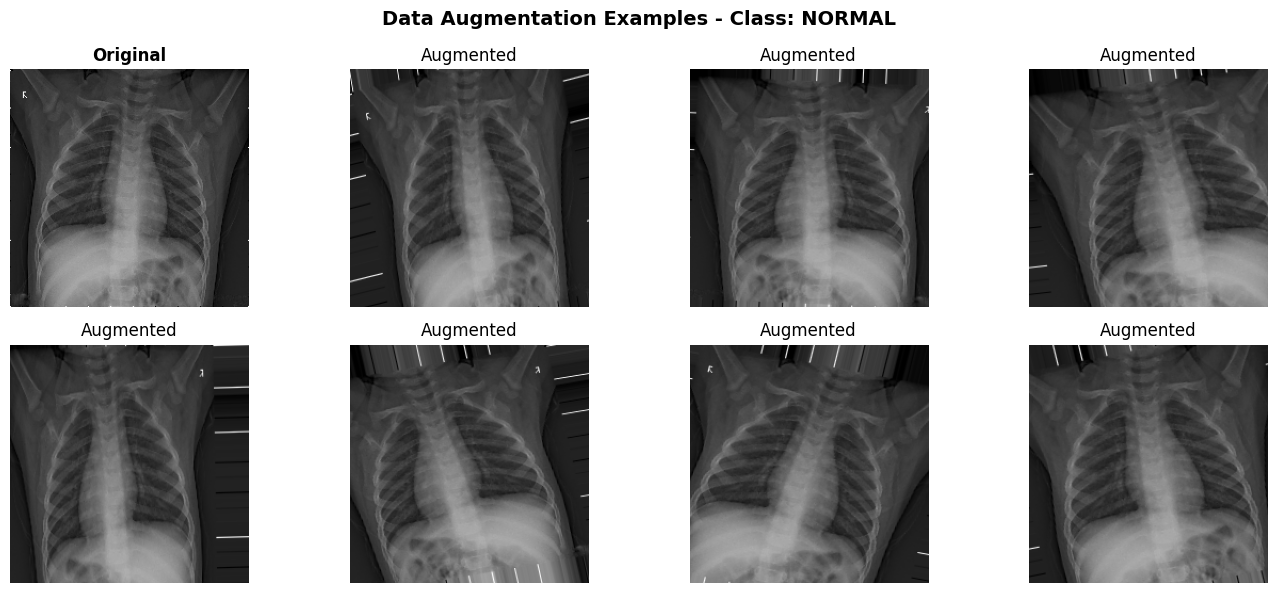

In [ ]:
sample_cls  = classes[0]
sample_path = os.path.join(train_dir, sample_cls)
sample_file = os.path.join(sample_path, os.listdir(sample_path)[0])

img       = tf.keras.preprocessing.image.load_img(sample_file, target_size=IMG_SIZE)
img_array = tf.keras.preprocessing.image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

aug_datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.15,
    horizontal_flip=True,
    fill_mode='nearest'
)
aug_gen = aug_datagen.flow(img_array, batch_size=1)

fig, axes = plt.subplots(2, 4, figsize=(14, 6))
fig.suptitle(f"Data Augmentation Examples - Class: {sample_cls.upper()}",
             fontsize=14, fontweight='bold')

axes[0, 0].imshow(img_array[0], cmap='gray')
axes[0, 0].set_title("Original", fontweight='bold')
axes[0, 0].axis('off')

for ax in axes.flatten()[1:]:
    aug_img = next(aug_gen)[0]
    ax.imshow(np.clip(aug_img, 0, 1), cmap='gray')
    ax.set_title("Augmented")
    ax.axis('off')

plt.tight_layout()
plt.show()

We use a **two-phase fine-tuning approach**:
- **Phase 1:** Train full network from scratch, LR = 1e-3, up to 20 epochs
- **Phase 2:** Fine-tune all layers with lower LR = 1e-4, up to 30 epochs

###  TASK 2 — SqueezeNet Architecture

In [ ]:
def fire_module(x, squeeze_filters, expand_filters):
    # Squeeze layer
    x = layers.Conv2D(squeeze_filters, (1, 1), activation='relu', padding='same')(x)
    # Expand layers
    expand_1x1 = layers.Conv2D(expand_filters, (1, 1), activation='relu', padding='same')(x)
    expand_3x3 = layers.Conv2D(expand_filters, (3, 3), activation='relu', padding='same')(x)
    # Concatenate
    x = layers.Concatenate()([expand_1x1, expand_3x3])
    return x

def build_squeezenet(input_shape=(224, 224, 3), num_classes=1):
    inputs = tf.keras.Input(shape=input_shape)

    # Initial convolution
    x = layers.Conv2D(96, (7, 7), strides=(2, 2), activation='relu', padding='same')(inputs)
    x = layers.MaxPooling2D((3, 3), strides=(2, 2))(x)

    # Fire modules
    x = fire_module(x, squeeze_filters=16, expand_filters=64)
    x = fire_module(x, squeeze_filters=16, expand_filters=64)
    x = fire_module(x, squeeze_filters=32, expand_filters=128)
    x = layers.MaxPooling2D((3, 3), strides=(2, 2))(x)

    x = fire_module(x, squeeze_filters=32, expand_filters=128)
    x = fire_module(x, squeeze_filters=48, expand_filters=192)
    x = fire_module(x, squeeze_filters=48, expand_filters=192)
    x = fire_module(x, squeeze_filters=64, expand_filters=256)
    x = layers.MaxPooling2D((3, 3), strides=(2, 2))(x)

    x = fire_module(x, squeeze_filters=64, expand_filters=256)

    # Classifier head
    x = layers.Dropout(0.5)(x)
    x = layers.Conv2D(512, (1, 1), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation='relu',
                      kernel_regularizer=tf.keras.regularizers.l2(0.001))(x)
    x = layers.Dropout(0.4)(x)

    if num_classes == 1:
        outputs = layers.Dense(1, activation='sigmoid')(x)
    else:
        outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs, outputs)
    return model

NUM_CLASSES = 1  # Binary classification

model = build_squeezenet(input_shape=(224, 224, 3), num_classes=NUM_CLASSES)
model.summary()

print(f"\nTotal parameters : {model.count_params():,}")
print(f"Model size       : {model.count_params() * 4 / 1024 / 1024:.2f} MB")

I0000 00:00:1775418910.813436      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1775418910.819581      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 112, 112,  │     14,208 │ input_layer[0][0] │
│                     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 55, 55,    │          0 │ conv2d[0][0]      │
│ (MaxPooling2D)      │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 55, 55,    │      1,552 │ max_pooling2d[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 55, 55,    │      1,088 │ conv2d_1[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 55, 55,    │      9,280 │ conv2d_1[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 55, 55,    │          0 │ conv2d_2[0][0],   │
│ (Concatenate)       │ 128)              │            │ conv2d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 55, 55,    │      2,064 │ concatenate[0][0] │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 55, 55,    │      1,088 │ conv2d_4[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 55, 55,    │      9,280 │ conv2d_4[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 55, 55,    │          0 │ conv2d_5[0][0],   │
│ (Concatenate)       │ 128)              │            │ conv2d_6[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 55, 55,    │      4,128 │ concatenate_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 55, 55,    │      4,224 │ conv2d_7[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 55, 55,    │     36,992 │ conv2d_7[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 55, 55,    │          0 │ conv2d_8[0][0],   │
│ (Concatenate)       │ 256)              │            │ conv2d_9[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 27, 27,    │          0 │ concatenate_2[0]… │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 27, 27,    │      8,224 │ max_pooling2d_1[

 Total params: 1,065,921 (4.07 MB)

 Trainable params: 1,064,897 (4.06 MB)

 Non-trainable params: 1,024 (4.00 KB)


Total parameters : 1,065,921
Model size       : 4.07 MB


###  TASK 2 — Phase 1 Training (Full Network)

In [ ]:
model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy',
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall')]
)

callbacks_phase1 = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    ),
    ModelCheckpoint(
        '/kaggle/working/best_phase1.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

print("Phase 1: Training SqueezeNet from scratch...")
history1 = model.fit(
    train_gen,
    epochs=20,
    validation_data=val_gen,
    callbacks=callbacks_phase1,
    class_weight=class_weight,
    verbose=1
)

print(f"\nBest Phase 1 Validation Accuracy : {max(history1.history['val_accuracy'])*100:.2f}%")

Phase 1: Training SqueezeNet from scratch...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20


I0000 00:00:1775418921.706771     148 service.cc:152] XLA service 0x7d6f181113c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775418921.706809     148 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1775418921.706813     148 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1775418923.318862     148 cuda_dnn.cc:529] Loaded cuDNN version 91002


  1/163 ━━━━━━━━━━━━━━━━━━━━ 55:51 21s/step - accuracy: 0.5938 - loss: 0.9458 - precision: 0.6667 - recall: 0.8182

I0000 00:00:1775418934.576129     148 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 864ms/step - accuracy: 0.7312 - loss: 0.6171 - precision: 0.9205 - recall: 0.6943
Epoch 1: val_accuracy improved from -inf to 0.62500, saving model to /kaggle/working/best_phase1.keras
163/163 ━━━━━━━━━━━━━━━━━━━━ 164s 885ms/step - accuracy: 0.7315 - loss: 0.6164 - precision: 0.9207 - recall: 0.6945 - val_accuracy: 0.6250 - val_loss: 2.7666 - val_precision: 0.5714 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 2/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 593ms/step - accuracy: 0.8155 - loss: 0.4092 - precision: 0.9702 - recall: 0.7751
Epoch 2: val_accuracy did not improve from 0.62500
163/163 ━━━━━━━━━━━━━━━━━━━━ 97s 595ms/step - accuracy: 0.8156 - loss: 0.4091 - precision: 0.9702 - recall: 0.7752 - val_accuracy: 0.5000 - val_loss: 7.6467 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 3/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 582ms/step - accuracy: 0.8336 - loss: 0.3667 - precision: 0.9702 - recall: 0.8023
Epoch 3: val_accuracy

###  TASK 2 — Phase 2 Fine-tuning (Lower LR)

In [ ]:
# Unfreeze all layers with lower learning rate
for layer in model.layers:
    layer.trainable = True

model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy',
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall')]
)

callbacks_phase2 = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=8,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=4,
        min_lr=1e-7,
        verbose=1
    ),
    ModelCheckpoint(
        '/kaggle/working/best_phase2.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

print("Phase 2: Fine-tuning all layers with lower learning rate...")
history2 = model.fit(
    train_gen,
    epochs=30,
    validation_data=val_gen,
    callbacks=callbacks_phase2,
    class_weight=class_weight,
    verbose=1
)

print(f"\nBest Phase 2 Validation Accuracy : {max(history2.history['val_accuracy'])*100:.2f}%")

Phase 2: Fine-tuning all layers with lower learning rate...
Epoch 1/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 617ms/step - accuracy: 0.8888 - loss: 0.2680 - precision: 0.9740 - recall: 0.8717
Epoch 1: val_accuracy improved from -inf to 0.50000, saving model to /kaggle/working/best_phase2.keras
163/163 ━━━━━━━━━━━━━━━━━━━━ 118s 631ms/step - accuracy: 0.8888 - loss: 0.2679 - precision: 0.9740 - recall: 0.8717 - val_accuracy: 0.5000 - val_loss: 2.9626 - val_precision: 0.5000 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 2/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 601ms/step - accuracy: 0.9087 - loss: 0.2213 - precision: 0.9817 - recall: 0.8939
Epoch 2: val_accuracy improved from 0.50000 to 0.56250, saving model to /kaggle/working/best_phase2.keras
163/163 ━━━━━━━━━━━━━━━━━━━━ 99s 604ms/step - accuracy: 0.9087 - loss: 0.2213 - precision: 0.9817 - recall: 0.8939 - val_accuracy: 0.5625 - val_loss: 0.9701 - val_precision: 0.5333 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 3/30
163/163 ━

###  TASK 2 — Feature Map Visualization

Visualizing layers: ['conv2d', 'conv2d_3', 'max_pooling2d_1']


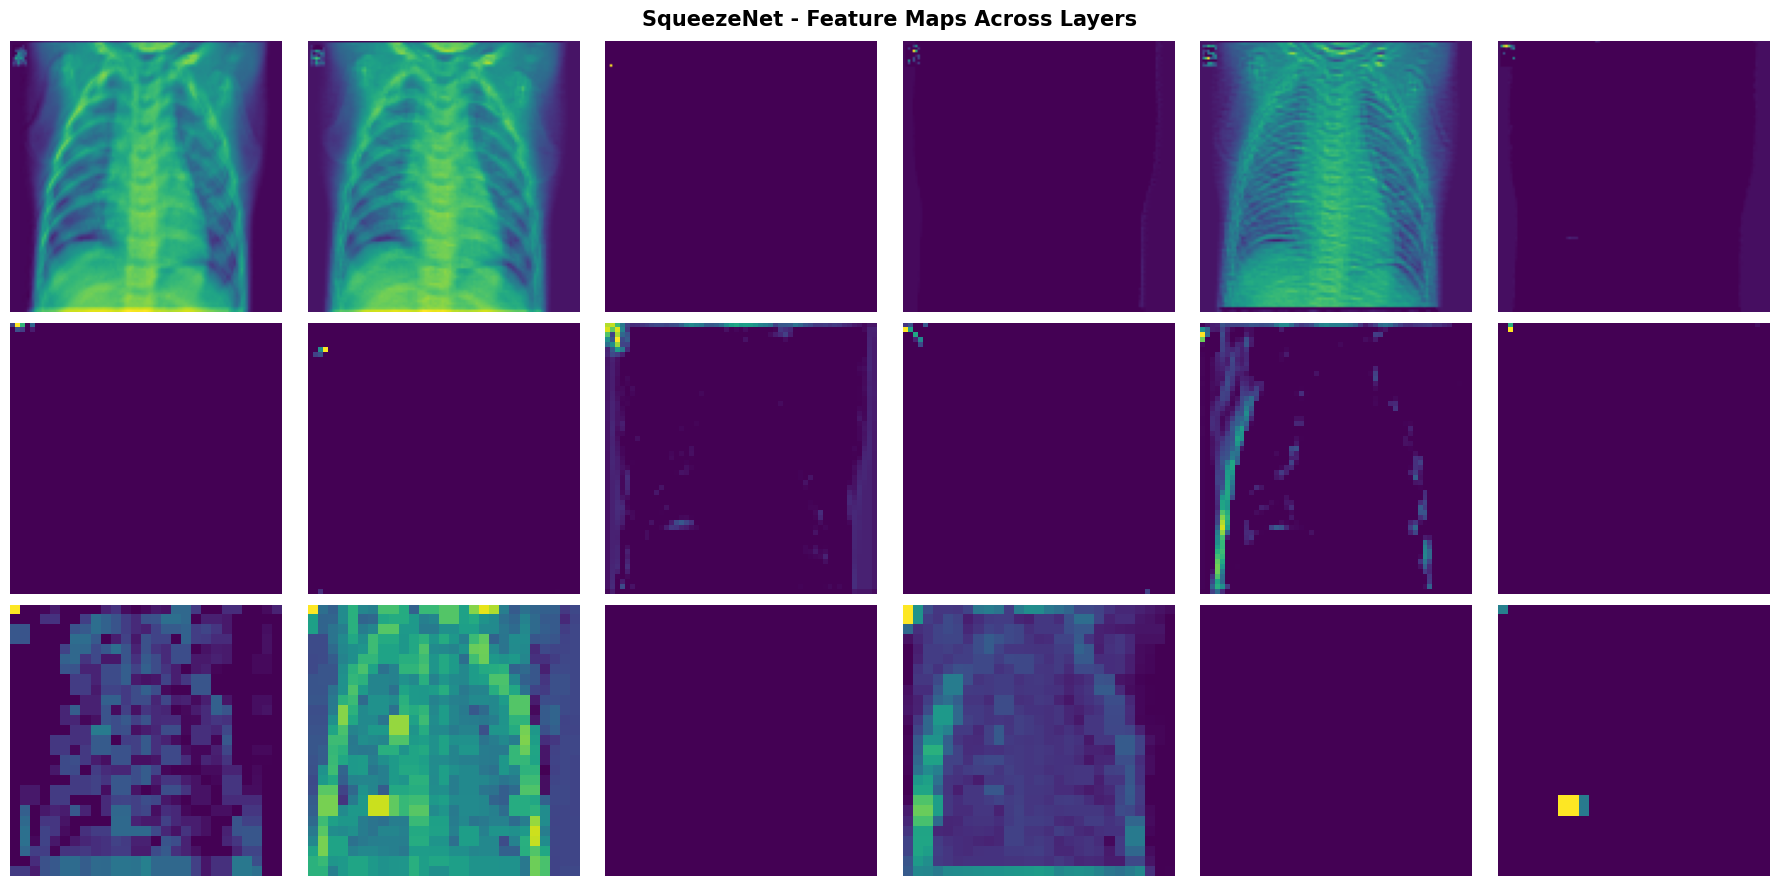

In [ ]:
sample_file = os.path.join(
    test_dir, classes[0],
    os.listdir(os.path.join(test_dir, classes[0]))[0]
)

img       = tf.keras.preprocessing.image.load_img(sample_file, target_size=(224, 224))
img_array = tf.keras.preprocessing.image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Pick 3 conv layers from SqueezeNet to visualize
layer_names = [
    model.layers[1].name,   # First conv layer
    model.layers[5].name,   # Early fire module output
    model.layers[15].name   # Mid fire module output
]

print("Visualizing layers:", layer_names)

feature_models = [
    models.Model(inputs=model.input,
                 outputs=model.get_layer(ln).output)
    for ln in layer_names
]

fig, axes = plt.subplots(3, 6, figsize=(18, 9))
fig.suptitle("SqueezeNet - Feature Maps Across Layers",
             fontsize=15, fontweight='bold')

for row, (fm_model, lname) in enumerate(zip(feature_models, layer_names)):
    fmaps = fm_model.predict(img_array, verbose=0)[0]
    for col in range(6):
        axes[row, col].imshow(fmaps[:, :, col], cmap='viridis')
        axes[row, col].axis('off')
    axes[row, 0].set_ylabel(lname, fontsize=8, rotation=0, labelpad=120)

plt.tight_layout()
plt.show()

###  TASK 2 — Training History Visualization

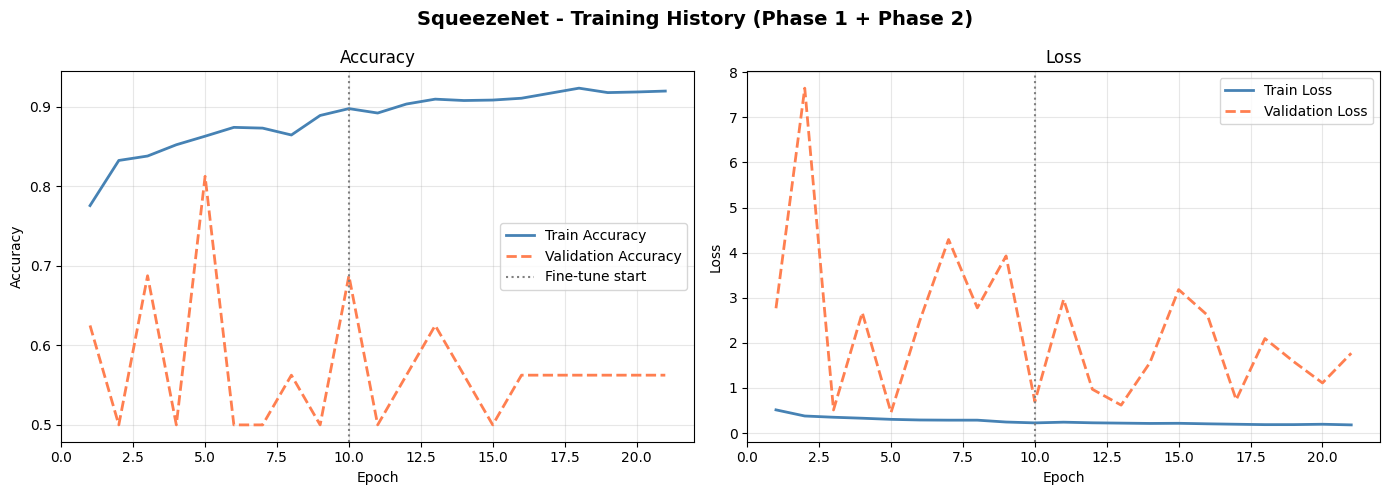

In [ ]:
def plot_history(h1, h2):
    acc   = h1.history['accuracy']     + h2.history['accuracy']
    val   = h1.history['val_accuracy'] + h2.history['val_accuracy']
    loss  = h1.history['loss']         + h2.history['loss']
    vloss = h1.history['val_loss']     + h2.history['val_loss']
    ep    = range(1, len(acc) + 1)
    split = len(h1.history['accuracy'])

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("SqueezeNet - Training History (Phase 1 + Phase 2)",
                 fontsize=14, fontweight='bold')

    ax1.plot(ep, acc,  label='Train Accuracy',      color='steelblue', linewidth=2)
    ax1.plot(ep, val,  label='Validation Accuracy',  color='coral',
             linestyle='--', linewidth=2)
    ax1.axvline(split, color='gray', linestyle=':',
                linewidth=1.5, label='Fine-tune start')
    ax1.set_title('Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax1.grid(alpha=0.3)

    ax2.plot(ep, loss,  label='Train Loss',      color='steelblue', linewidth=2)
    ax2.plot(ep, vloss, label='Validation Loss', color='coral',
             linestyle='--', linewidth=2)
    ax2.axvline(split, color='gray', linestyle=':', linewidth=1.5)
    ax2.set_title('Loss')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_history(history1, history2)

###  TASK 3 — Model Evaluation on Test Set

In [ ]:
print("Evaluating on test set...")
results  = model.evaluate(test_gen, verbose=1)
test_loss = results[0]
test_acc  = results[1]

print(f"\nTest Accuracy  : {test_acc * 100:.2f}%")
print(f"Test Loss      : {test_loss:.4f}")

y_pred_probs = model.predict(test_gen, verbose=1)
y_pred       = (y_pred_probs > 0.5).astype(int).flatten()
y_true       = test_gen.classes

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=classes))

Evaluating on test set...
20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 310ms/step - accuracy: 0.8706 - loss: 0.3585 - precision: 0.5237 - recall: 0.5995

Test Accuracy  : 87.18%
Test Loss      : 0.3296
20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 272ms/step

Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.82      0.84      0.83       234
   PNEUMONIA       0.90      0.89      0.90       390

    accuracy                           0.87       624
   macro avg       0.86      0.87      0.86       624
weighted avg       0.87      0.87      0.87       624



###  TASK 3 — Confusion Matrix

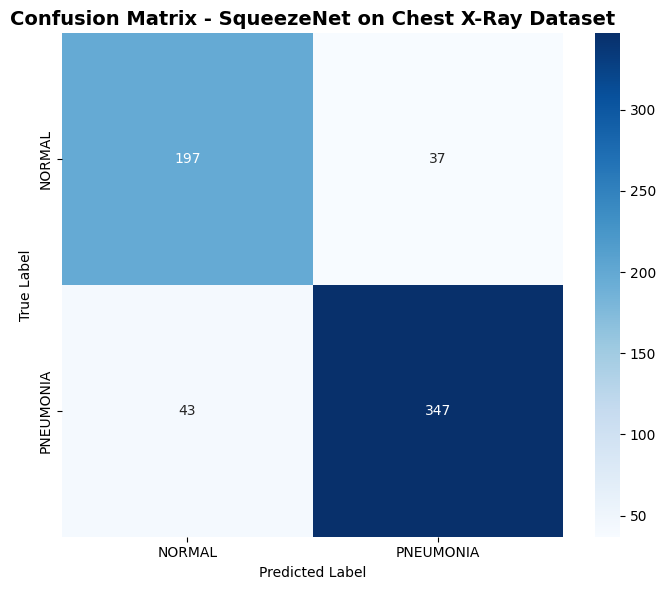

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=[c.upper() for c in classes],
    yticklabels=[c.upper() for c in classes]
)
plt.title('Confusion Matrix - SqueezeNet on Chest X-Ray Dataset',
          fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

###  TASK 3 — Performance Metrics Summary & Research Paper Comparison Table

In [ ]:
prec = precision_score(y_true, y_pred, average='weighted')
rec  = recall_score(y_true,  y_pred,   average='weighted')
f1   = f1_score(y_true,      y_pred,   average='weighted')

print(" " * 60)
print("           PERFORMANCE METRICS SUMMARY")
print(" " * 60)
print(f"  Accuracy  : {test_acc * 100:.2f}%")
print(f"  Precision : {prec * 100:.2f}%")
print(f"  Recall    : {rec  * 100:.2f}%")
print(f"  F1-Score  : {f1   * 100:.2f}%")
print(" " * 60)

comparison = {
    "Model"       : ["SqueezeNet (Original Paper)",   "Our Implementation"],
    "Accuracy"    : ["57.5% (ImageNet Top-1)",         f"{test_acc * 100:.2f}% (Chest X-Ray)"],
    "Dataset"     : ["ImageNet (1000 classes)",        "Chest X-Ray (2 classes)"],
    "Input Size"  : ["224x224",                        "224x224"],
    "Parameters"  : ["1.2 Million",                    f"{model.count_params():,}"],
    "Model Size"  : ["< 0.5 MB",                       f"{model.count_params()*4/1024/1024:.2f} MB"]
}

df = pd.DataFrame(comparison)
print("\nComparison with SqueezeNet Research Paper:")
print(df.to_string(index=False))

                                                            
           PERFORMANCE METRICS SUMMARY
                                                            
  Accuracy  : 87.18%
  Precision : 87.26%
  Recall    : 87.18%
  F1-Score  : 87.21%
                                                            

Comparison with SqueezeNet Research Paper:
                      Model               Accuracy                 Dataset Input Size  Parameters Model Size
SqueezeNet (Original Paper) 57.5% (ImageNet Top-1) ImageNet (1000 classes)    224x224 1.2 Million   < 0.5 MB
         Our Implementation   87.18% (Chest X-Ray) Chest X-Ray (2 classes)    224x224   1,065,921    4.07 MB


###  TASK 3 — Per-Class Accuracy

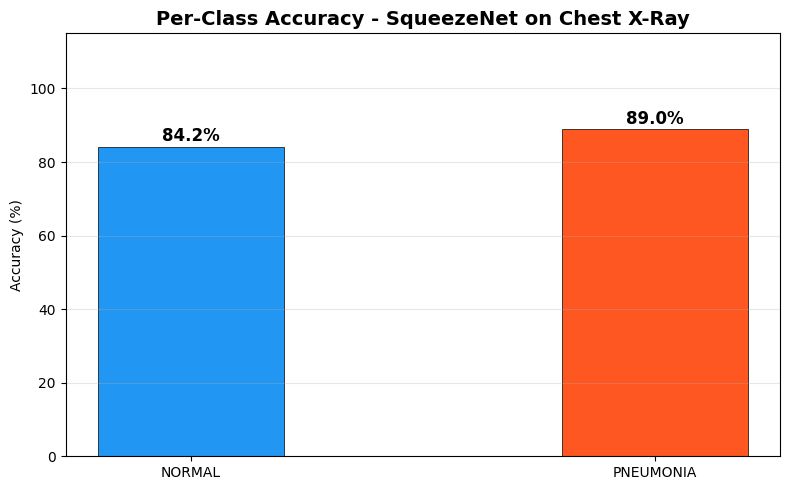

In [ ]:
per_class_acc = cm.diagonal() / cm.sum(axis=1)

plt.figure(figsize=(8, 5))
colors = ['#2196F3', '#FF5722']
bars   = plt.bar(
    [c.upper() for c in classes],
    per_class_acc * 100,
    color=colors,
    edgecolor='black',
    linewidth=0.5,
    width=0.4
)
plt.title('Per-Class Accuracy - SqueezeNet on Chest X-Ray',
          fontsize=14, fontweight='bold')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 115)
for bar, acc in zip(bars, per_class_acc):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1.5,
        f'{acc * 100:.1f}%',
        ha='center', fontweight='bold', fontsize=12
    )
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

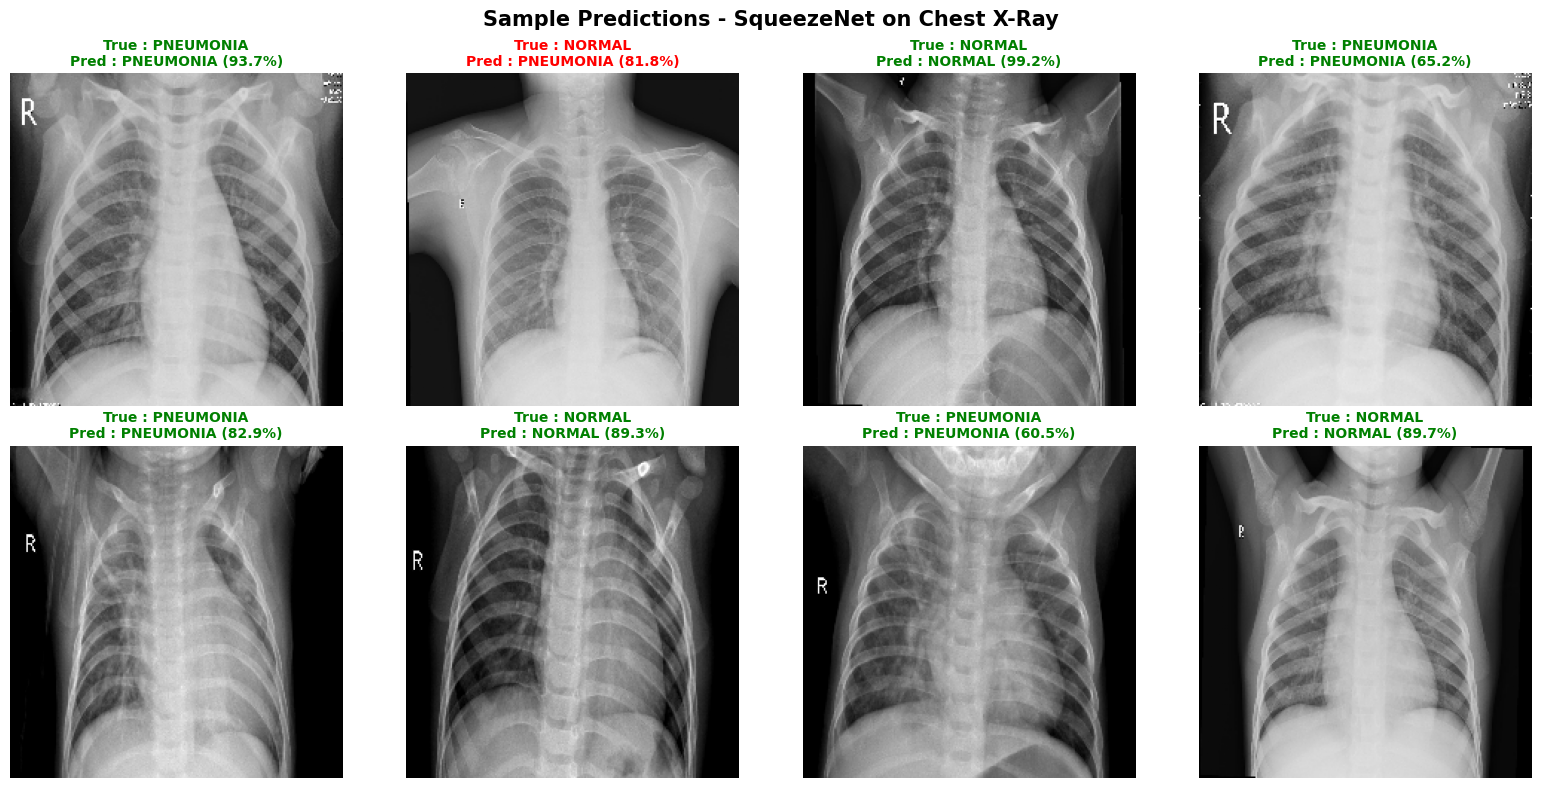

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle("Sample Predictions - SqueezeNet on Chest X-Ray",
             fontsize=15, fontweight='bold')

for ax in axes.flatten():
    cls      = random.choice(classes)
    cls_path = os.path.join(test_dir, cls)
    if not os.path.exists(cls_path) or len(os.listdir(cls_path)) == 0:
        continue
    img_file = random.choice(os.listdir(cls_path))
    img      = tf.keras.preprocessing.image.load_img(
                   os.path.join(cls_path, img_file),
                   target_size=(224, 224))
    arr      = tf.keras.preprocessing.image.img_to_array(img) / 255.0
    pred_prob  = model.predict(np.expand_dims(arr, 0), verbose=0)[0][0]
    pred_idx   = int(pred_prob > 0.5)
    pred_cls   = classes[pred_idx]
    confidence = pred_prob * 100 if pred_idx == 1 else (1 - pred_prob) * 100

    ax.imshow(arr, cmap='gray')
    color = 'green' if pred_cls == cls else 'red'
    ax.set_title(
        f"True : {cls}\nPred : {pred_cls} ({confidence:.1f}%)",
        color=color, fontsize=10, fontweight='bold'
    )
    ax.axis('off')

plt.tight_layout()
plt.show()

Github Repository Link: